<a href="https://colab.research.google.com/github/ocalin911/Deep-Learning-Models-of-Mathematical-Physics/blob/Volume-II/Chapter-5-Thermodynamics/Untitled185.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Kinetics Neural Discovery: Irreversible Reactions**

**Water formation**

The ODE associated to the dynamics of the equation
$$2H_2 + O_2 \longrightarrow 2H_2$$
is
$$
 z'(t) = k (x_1^0 - 2 z(t))^{2} (x_2^0- z(t)), \qquad z(0) =0,
$$


where $x_1^0$ is the initial concentration of Hydrogen, $x_2^0$ is the initial concentration of Oxygen and $\alpha_1=2$ and $\alpha_2=1$.



Since this equation does not have an explict solution, we use Runge--Kutta method to plot the solution in the case $k=0.25$.

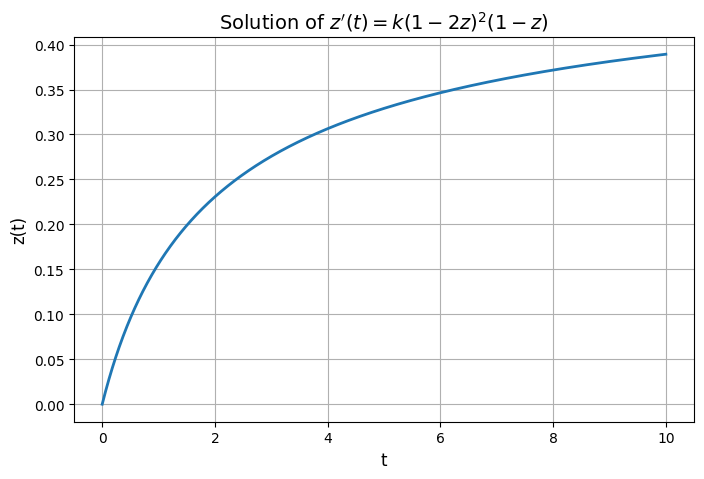

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------
# ODE:
# z'(t) = k (1 - 2 z)^2 (1 - z)
# z(0) = 0
# ---------------------------------------------------

# reaction constant
k = 0.250

# right-hand side of the ODE
def f(t, z):
    return k * (1 - 2*z)**2 * (1 - z)

# ---------------------------------------------------
# Runge--Kutta 4th order method
# ---------------------------------------------------

# time interval
t0 = 0.0
T  = 10.0

# number of steps
N = 1000

# step size
h = (T - t0)/N

# arrays
t = np.linspace(t0, T, N+1)
z = np.zeros(N+1)

# initial condition
z[0] = 0.0

# RK4 iteration
for n in range(N):

    k1 = f(t[n], z[n])

    k2 = f(
        t[n] + h/2,
        z[n] + h*k1/2
    )

    k3 = f(
        t[n] + h/2,
        z[n] + h*k2/2
    )

    k4 = f(
        t[n] + h,
        z[n] + h*k3
    )

    z[n+1] = z[n] + (h/6)*(k1 + 2*k2 + 2*k3 + k4)

# ---------------------------------------------------
# Plot
# ---------------------------------------------------

plt.figure(figsize=(8,5))

plt.plot(t, z, linewidth=2)

plt.xlabel("t", fontsize=12)
plt.ylabel("z(t)", fontsize=12)

plt.title(
    r"Solution of $z'(t)=k(1-2z)^2(1-z)$",
    fontsize=14
)

plt.grid(True)

plt.show()

We use a PINN approach to recover $k$, $\alpha_1$, $\alpha_2$ and the solution $z(t)$.

Epoch     0 | Loss = 4.1785e-01 | k = 0.2000 | a1 = 2.0000 | a2 = 1.0000
Epoch   500 | Loss = 2.4490e-05 | k = 0.2403 | a1 = 1.8731 | a2 = 0.9327
Epoch  1000 | Loss = 7.0816e-06 | k = 0.2494 | a1 = 1.9942 | a2 = 0.9900
Epoch  1500 | Loss = 6.0169e-06 | k = 0.2515 | a1 = 2.0221 | a2 = 1.0050
Epoch  2000 | Loss = 5.7529e-06 | k = 0.2516 | a1 = 2.0228 | a2 = 1.0081
Epoch  2500 | Loss = 5.3800e-06 | k = 0.2516 | a1 = 2.0209 | a2 = 1.0107
Epoch  3000 | Loss = 4.8361e-06 | k = 0.2515 | a1 = 2.0182 | a2 = 1.0139
Epoch  3500 | Loss = 4.0550e-06 | k = 0.2514 | a1 = 2.0146 | a2 = 1.0177
Epoch  4000 | Loss = 3.0053e-06 | k = 0.2512 | a1 = 2.0098 | a2 = 1.0219
Epoch  4500 | Loss = 1.8153e-06 | k = 0.2510 | a1 = 2.0038 | a2 = 1.0263
Epoch  5000 | Loss = 1.0672e-06 | k = 0.2508 | a1 = 1.9979 | a2 = 1.0309
Epoch  5500 | Loss = 5.5533e-07 | k = 0.2506 | a1 = 1.9927 | a2 = 1.0354


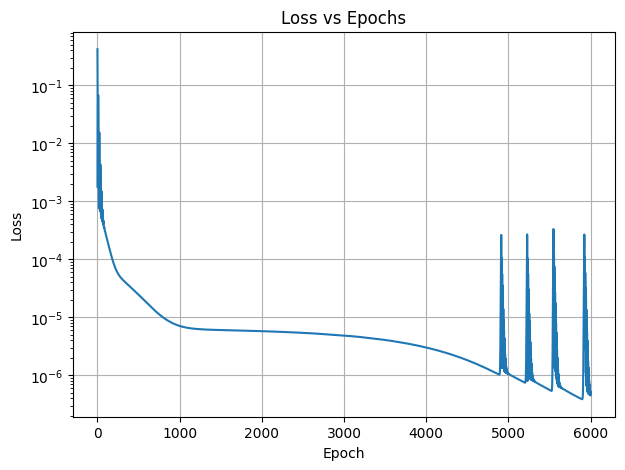

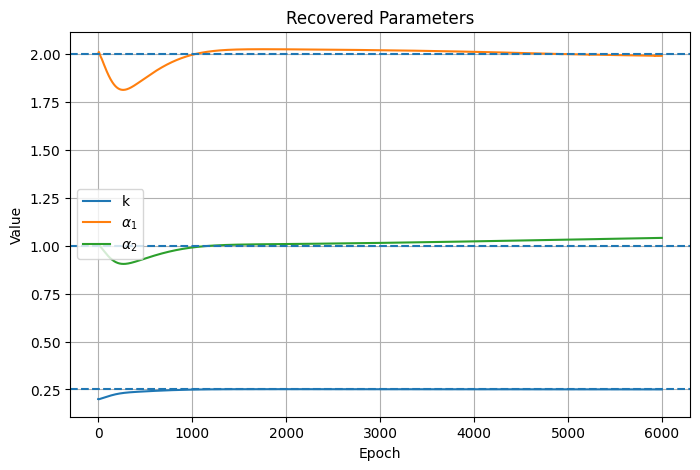

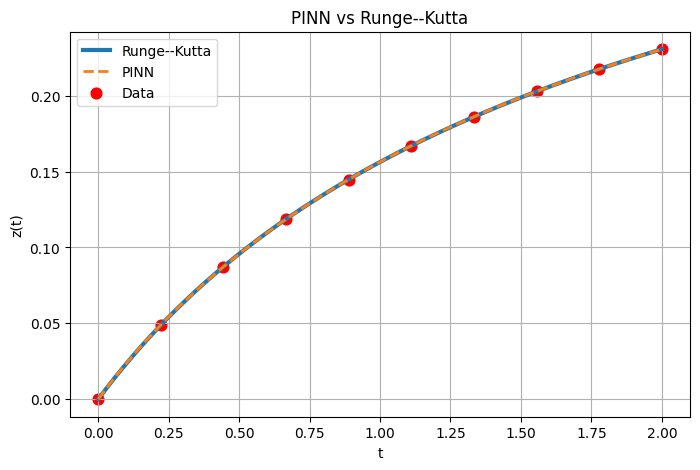


Recovered Parameters
True k          = 0.25
Recovered k     = 0.250482

True alpha1     = 2.0
Recovered alpha1= 1.989126

True alpha2     = 1.0
Recovered alpha2= 1.040051


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

tf.keras.backend.set_floatx('float32')

# ============================================================
# TRUE PARAMETERS
# ============================================================

k_true = 0.25
alpha1_true = 2.0
alpha2_true = 1.0

# ============================================================
# REFERENCE SOLUTION (Runge--Kutta)
# ============================================================

def f(t, z):
    return (
        k_true
        * (1 - 2*z)**alpha1_true
        * (1 - z)**alpha2_true
    )

# Time interval
T = 2.0

# RK4 discretization
N_rk = 4000

t_rk = np.linspace(0, T, N_rk + 1)
h = T / N_rk

z_rk = np.zeros(N_rk + 1)

# Initial condition
z_rk[0] = 0.0

# RK4 loop
for n in range(N_rk):

    k1 = f(t_rk[n], z_rk[n])

    k2 = f(
        t_rk[n] + h/2,
        z_rk[n] + h*k1/2
    )

    k3 = f(
        t_rk[n] + h/2,
        z_rk[n] + h*k2/2
    )

    k4 = f(
        t_rk[n] + h,
        z_rk[n] + h*k3
    )

    z_rk[n+1] = (
        z_rk[n]
        + (h/6)*(k1 + 2*k2 + 2*k3 + k4)
    )

# ============================================================
# COLLECT ONLY 10 DATA POINTS
# ============================================================

N_data = 10

idx = np.linspace(0, N_rk, N_data, dtype=int)

t_data = t_rk[idx].reshape(-1,1)
z_data = z_rk[idx].reshape(-1,1)

# ============================================================
# BUILD THE PINN
# ============================================================

model = tf.keras.Sequential([

    tf.keras.layers.Input(shape=(1,)),

    tf.keras.layers.Dense(
        64,
        activation='tanh'
    ),

    tf.keras.layers.Dense(
        64,
        activation='tanh'
    ),

    tf.keras.layers.Dense(
        64,
        activation='tanh'
    ),

    tf.keras.layers.Dense(1)

])

# ============================================================
# POSITIVE PARAMETRIZATION
# We optimize logarithms
# ============================================================

k_var = tf.Variable(
    np.log(0.20),
    dtype=tf.float32
)

a1_var = tf.Variable(
    np.log(2.0),
    dtype=tf.float32
)

a2_var = tf.Variable(
    np.log(1.0),
    dtype=tf.float32
)

# ============================================================
# HARD EMBEDDING
#
# z(0)=0
# and 0 <= z(t) <= 1/2
# ============================================================

def z_theta(t):

    raw = model(t)

    return (
        0.5
        * tf.sigmoid(raw)
        * t/(t + 1.0)
    )

# ============================================================
# COLLOCATION POINTS
# ============================================================

N_col = 300

t_col = np.linspace(
    0,
    T,
    N_col
).reshape(-1,1).astype(np.float32)

# ============================================================
# TRAINING
# ============================================================

optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.001
)

epochs = 6000

loss_history = []

k_history  = []
a1_history = []
a2_history = []

# ============================================================

for epoch in range(epochs):

    with tf.GradientTape() as tape:

        # ----------------------------------------
        # Positive parameters
        # ----------------------------------------

        k      = tf.exp(k_var)
        alpha1 = tf.exp(a1_var)
        alpha2 = tf.exp(a2_var)

        # ----------------------------------------
        # DATA LOSS
        # ----------------------------------------

        t_d = tf.convert_to_tensor(
            t_data,
            dtype=tf.float32
        )

        z_d = tf.convert_to_tensor(
            z_data,
            dtype=tf.float32
        )

        z_pred_data = z_theta(t_d)

        loss_data = tf.reduce_mean(
            (z_pred_data - z_d)**2
        )

        # ----------------------------------------
        # PHYSICS LOSS
        # ----------------------------------------

        t_f = tf.convert_to_tensor(t_col)

        with tf.GradientTape() as tape2:

            tape2.watch(t_f)

            z_pred = z_theta(t_f)

        dzdt = tape2.gradient(
            z_pred,
            t_f
        )

        # Positivity protection
        term1 = tf.abs(
            1 - 2*z_pred
        ) + 1e-6

        term2 = tf.abs(
            1 - z_pred
        ) + 1e-6

        rhs = (
            k
            * tf.pow(term1, alpha1)
            * tf.pow(term2, alpha2)
        )

        residual = dzdt - rhs

        loss_phys = tf.reduce_mean(
            residual**2
        )

        # ----------------------------------------
        # TOTAL LOSS
        # Stronger data anchoring
        # ----------------------------------------

        loss = (
            100.0 * loss_data
            + loss_phys
        )

    # ----------------------------------------
    # TRAINABLE VARIABLES
    # ----------------------------------------

    variables = (
        model.trainable_variables
        + [k_var, a1_var, a2_var]
    )

    grads = tape.gradient(
        loss,
        variables
    )

    optimizer.apply_gradients(
        zip(grads, variables)
    )

    # ----------------------------------------
    # STORE HISTORY
    # ----------------------------------------

    loss_history.append(
        loss.numpy()
    )

    k_history.append(
        k.numpy()
    )

    a1_history.append(
        alpha1.numpy()
    )

    a2_history.append(
        alpha2.numpy()
    )

    # ----------------------------------------
    # PRINT
    # ----------------------------------------

    if epoch % 500 == 0:

        print(
            f"Epoch {epoch:5d} | "
            f"Loss = {loss.numpy():.4e} | "
            f"k = {k.numpy():.4f} | "
            f"a1 = {alpha1.numpy():.4f} | "
            f"a2 = {alpha2.numpy():.4f}"
        )

# ============================================================
# PREDICTIONS
# ============================================================

t_test = t_rk.reshape(-1,1).astype(np.float32)

z_nn = z_theta(
    tf.convert_to_tensor(t_test)
).numpy().flatten()

# ============================================================
# PLOT LOSS
# ============================================================

plt.figure(figsize=(7,5))

plt.plot(loss_history)

plt.yscale('log')

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Loss vs Epochs")

plt.grid(True)

plt.show()

# ============================================================
# PLOT PARAMETERS
# ============================================================

plt.figure(figsize=(8,5))

plt.plot(
    k_history,
    label='k'
)

plt.plot(
    a1_history,
    label=r'$\alpha_1$'
)

plt.plot(
    a2_history,
    label=r'$\alpha_2$'
)

plt.axhline(
    k_true,
    linestyle='--'
)

plt.axhline(
    alpha1_true,
    linestyle='--'
)

plt.axhline(
    alpha2_true,
    linestyle='--'
)

plt.xlabel("Epoch")

plt.ylabel("Value")

plt.title("Recovered Parameters")

plt.legend()

plt.grid(True)

plt.show()

# ============================================================
# PLOT SOLUTION
# ============================================================

plt.figure(figsize=(8,5))

plt.plot(
    t_rk,
    z_rk,
    linewidth=3,
    label='Runge--Kutta'
)

plt.plot(
    t_rk,
    z_nn,
    '--',
    linewidth=2,
    label='PINN'
)

plt.scatter(
    t_data,
    z_data,
    color='red',
    s=60,
    label='Data'
)

plt.xlabel("t")

plt.ylabel("z(t)")

plt.title(
    "PINN vs Runge--Kutta"
)

plt.legend()

plt.grid(True)

plt.show()

# ============================================================
# FINAL RESULTS
# ============================================================

print("\n============================")
print("Recovered Parameters")
print("============================")

print(f"True k          = {k_true}")
print(f"Recovered k     = {k.numpy():.6f}")

print()

print(f"True alpha1     = {alpha1_true}")
print(f"Recovered alpha1= {alpha1.numpy():.6f}")

print()

print(f"True alpha2     = {alpha2_true}")
print(f"Recovered alpha2= {alpha2.numpy():.6f}")

We see that the above recovery is almost perfect.

We attempt next to recover the same things, but we add a 5\% noise to the data:

Epoch     0 | Loss = 3.8766e-02 | k = 0.2000 | a1 = 2.0000 | a2 = 1.0000
Epoch   500 | Loss = 1.0099e-03 | k = 0.2388 | a1 = 1.8528 | a2 = 0.9225
Epoch  1000 | Loss = 9.9486e-04 | k = 0.2491 | a1 = 1.9893 | a2 = 0.9840
Epoch  1500 | Loss = 9.9236e-04 | k = 0.2542 | a1 = 2.0536 | a2 = 1.0127
Epoch  2000 | Loss = 9.9210e-04 | k = 0.2554 | a1 = 2.0688 | a2 = 1.0198
Epoch  2500 | Loss = 9.9191e-04 | k = 0.2555 | a1 = 2.0689 | a2 = 1.0203
Epoch  3000 | Loss = 9.9161e-04 | k = 0.2552 | a1 = 2.0658 | a2 = 1.0191
Epoch  3500 | Loss = 9.9116e-04 | k = 0.2549 | a1 = 2.0606 | a2 = 1.0164
Epoch  4000 | Loss = 9.9062e-04 | k = 0.2543 | a1 = 2.0535 | a2 = 1.0114
Epoch  4500 | Loss = 9.9018e-04 | k = 0.2540 | a1 = 2.0495 | a2 = 1.0058
Epoch  5000 | Loss = 9.9011e-04 | k = 0.2538 | a1 = 2.0497 | a2 = 1.0003
Epoch  5500 | Loss = 9.8947e-04 | k = 0.2538 | a1 = 2.0525 | a2 = 0.9940


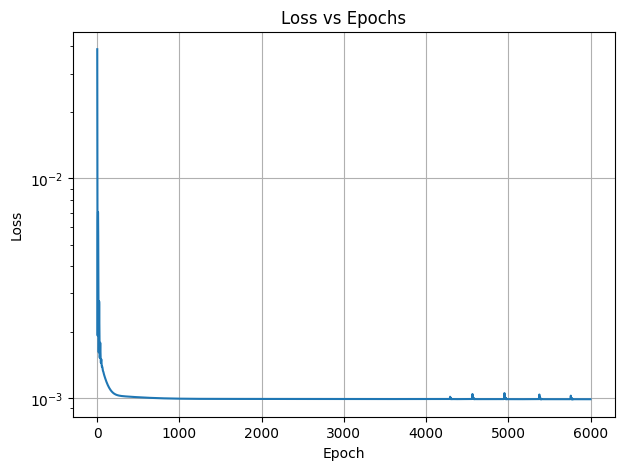

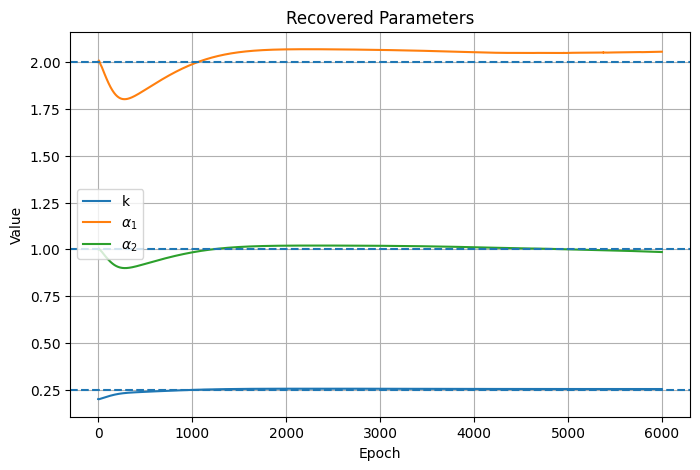

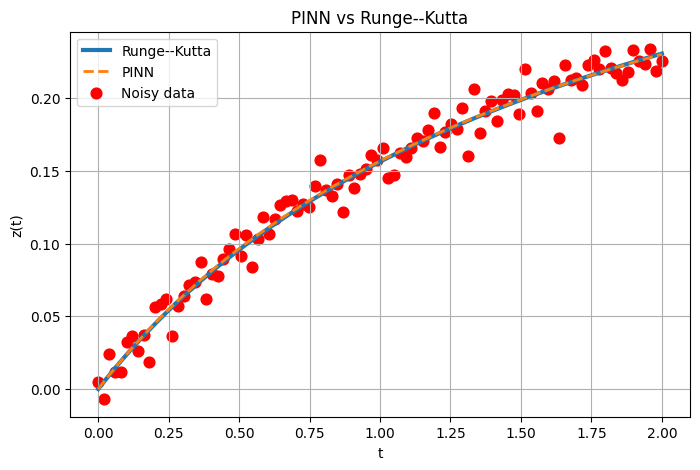


Recovered Parameters
True k           = 0.25
Recovered k      = 0.253735

True alpha1      = 2.0
Recovered alpha1 = 2.056248

True alpha2      = 1.0
Recovered alpha2 = 0.985693


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

tf.keras.backend.set_floatx('float32')

# ============================================================
# TRUE PARAMETERS
# ============================================================

k_true = 0.25
alpha1_true = 2.0
alpha2_true = 1.0

# ============================================================
# REFERENCE SOLUTION (Runge--Kutta)
# ============================================================

def f(t, z):

    return (
        k_true
        * (1 - 2*z)**alpha1_true
        * (1 - z)**alpha2_true
    )

# Time interval
T = 2.0

# RK4 discretization
N_rk = 4000

t_rk = np.linspace(0, T, N_rk + 1)

h = T / N_rk

z_rk = np.zeros(N_rk + 1)

# Initial condition
z_rk[0] = 0.0

# RK4 loop
for n in range(N_rk):

    k1 = f(t_rk[n], z_rk[n])

    k2 = f(
        t_rk[n] + h/2,
        z_rk[n] + h*k1/2
    )

    k3 = f(
        t_rk[n] + h/2,
        z_rk[n] + h*k2/2
    )

    k4 = f(
        t_rk[n] + h,
        z_rk[n] + h*k3
    )

    z_rk[n+1] = (
        z_rk[n]
        + (h/6)*(k1 + 2*k2 + 2*k3 + k4)
    )

# ============================================================
# COLLECT ONLY 100 DATA POINTS
# ============================================================

N_data = 100

idx = np.linspace(
    0,
    N_rk,
    N_data,
    dtype=int
)

t_data = t_rk[idx].reshape(-1,1)

z_data_clean = z_rk[idx].reshape(-1,1)

# ============================================================
# ADD SMALL NOISE
# ============================================================

noise_level = 0.01

np.random.seed(1234)

noise = noise_level * np.random.randn(*z_data_clean.shape)

z_data = z_data_clean + noise

# ============================================================
# BUILD THE PINN
# ============================================================

model = tf.keras.Sequential([

    tf.keras.layers.Input(shape=(1,)),

    tf.keras.layers.Dense(
        64,
        activation='tanh'
    ),

    tf.keras.layers.Dense(
        64,
        activation='tanh'
    ),

    tf.keras.layers.Dense(
        64,
        activation='tanh'
    ),

    tf.keras.layers.Dense(1)

])

# ============================================================
# POSITIVE PARAMETRIZATION
# ============================================================

k_var = tf.Variable(
    np.log(0.20),
    dtype=tf.float32
)

a1_var = tf.Variable(
    np.log(2.0),
    dtype=tf.float32
)

a2_var = tf.Variable(
    np.log(1.0),
    dtype=tf.float32
)

# ============================================================
# HARD EMBEDDING
# z(0)=0 and 0 <= z(t) <= 1/2
# ============================================================

def z_theta(t):

    raw = model(t)

    return (
        0.5
        * tf.sigmoid(raw)
        * t/(t + 1.0)
    )

# ============================================================
# COLLOCATION POINTS
# ============================================================

N_col = 300

t_col = np.linspace(
    0,
    T,
    N_col
).reshape(-1,1).astype(np.float32)

# ============================================================
# TRAINING
# ============================================================

optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.001
)

epochs = 6000

loss_history = []

k_history  = []
a1_history = []
a2_history = []

# ============================================================

for epoch in range(epochs):

    with tf.GradientTape() as tape:

        # ----------------------------------------
        # Positive parameters
        # ----------------------------------------

        k      = tf.exp(k_var)
        alpha1 = tf.exp(a1_var)
        alpha2 = tf.exp(a2_var)

        # ----------------------------------------
        # DATA LOSS
        # ----------------------------------------

        t_d = tf.convert_to_tensor(
            t_data,
            dtype=tf.float32
        )

        z_d = tf.convert_to_tensor(
            z_data,
            dtype=tf.float32
        )

        z_pred_data = z_theta(t_d)

        loss_data = tf.reduce_mean(
            (z_pred_data - z_d)**2
        )

        # ----------------------------------------
        # PHYSICS LOSS
        # ----------------------------------------

        t_f = tf.convert_to_tensor(t_col)

        with tf.GradientTape() as tape2:

            tape2.watch(t_f)

            z_pred = z_theta(t_f)

        dzdt = tape2.gradient(
            z_pred,
            t_f
        )

        term1 = tf.abs(
            1 - 2*z_pred
        ) + 1e-6

        term2 = tf.abs(
            1 - z_pred
        ) + 1e-6

        rhs = (
            k
            * tf.pow(term1, alpha1)
            * tf.pow(term2, alpha2)
        )

        residual = dzdt - rhs

        loss_phys = tf.reduce_mean(
            residual**2
        )

        # ----------------------------------------
        # TOTAL LOSS
        # ----------------------------------------

        loss = (
            10.0 * loss_data
            + loss_phys
        )

    # ----------------------------------------
    # TRAINABLE VARIABLES
    # ----------------------------------------

    variables = (
        model.trainable_variables
        + [k_var, a1_var, a2_var]
    )

    grads = tape.gradient(
        loss,
        variables
    )

    optimizer.apply_gradients(
        zip(grads, variables)
    )

    # ----------------------------------------
    # STORE HISTORY
    # ----------------------------------------

    loss_history.append(
        loss.numpy()
    )

    k_history.append(
        k.numpy()
    )

    a1_history.append(
        alpha1.numpy()
    )

    a2_history.append(
        alpha2.numpy()
    )

    # ----------------------------------------
    # PRINT
    # ----------------------------------------

    if epoch % 500 == 0:

        print(
            f"Epoch {epoch:5d} | "
            f"Loss = {loss.numpy():.4e} | "
            f"k = {k.numpy():.4f} | "
            f"a1 = {alpha1.numpy():.4f} | "
            f"a2 = {alpha2.numpy():.4f}"
        )

# ============================================================
# PREDICTIONS
# ============================================================

t_test = t_rk.reshape(-1,1).astype(np.float32)

z_nn = z_theta(
    tf.convert_to_tensor(t_test)
).numpy().flatten()

# ============================================================
# PLOT LOSS
# ============================================================

plt.figure(figsize=(7,5))

plt.plot(loss_history)

plt.yscale('log')

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Loss vs Epochs")

plt.grid(True)

plt.show()

# ============================================================
# PLOT PARAMETERS
# ============================================================

plt.figure(figsize=(8,5))

plt.plot(
    k_history,
    label='k'
)

plt.plot(
    a1_history,
    label=r'$\alpha_1$'
)

plt.plot(
    a2_history,
    label=r'$\alpha_2$'
)

plt.axhline(
    k_true,
    linestyle='--'
)

plt.axhline(
    alpha1_true,
    linestyle='--'
)

plt.axhline(
    alpha2_true,
    linestyle='--'
)

plt.xlabel("Epoch")

plt.ylabel("Value")

plt.title("Recovered Parameters")

plt.legend()

plt.grid(True)

plt.show()

# ============================================================
# PLOT SOLUTION
# ============================================================

plt.figure(figsize=(8,5))

plt.plot(
    t_rk,
    z_rk,
    linewidth=3,
    label='Runge--Kutta'
)

plt.plot(
    t_rk,
    z_nn,
    '--',
    linewidth=2,
    label='PINN'
)

plt.scatter(
    t_data,
    z_data,
    color='red',
    s=60,
    label='Noisy data'
)

plt.xlabel("t")

plt.ylabel("z(t)")

plt.title(
    "PINN vs Runge--Kutta"
)

plt.legend()

plt.grid(True)

plt.show()

# ============================================================
# FINAL RESULTS
# ============================================================

print("\n============================")
print("Recovered Parameters")
print("============================")

print(f"True k           = {k_true}")
print(f"Recovered k      = {k.numpy():.6f}")

print()

print(f"True alpha1      = {alpha1_true}")
print(f"Recovered alpha1 = {alpha1.numpy():.6f}")

print()

print(f"True alpha2      = {alpha2_true}")
print(f"Recovered alpha2 = {alpha2.numpy():.6f}")